In [64]:
#23.1
import folium
m = folium.Map(location=[10.761092724722472, 106.66844038453584], zoom_start=16)

# Tạo các nhóm lớp dữ liệu để bật và tắt
fg_school = folium.FeatureGroup(name='Trường học')
fg_hospital = folium.FeatureGroup(name='Bệnh viện')
fg_park_mall = folium.FeatureGroup(name='Giải trí & Công viên')

# 1. UEH Cơ sở B
folium.Marker(
    location=[10.761092724722472, 106.66844038453584],
    popup='<b>UEH Cơ sở B</b><br>Đại học Kinh tế TP.HCM',
    icon=folium.Icon(color='orange', icon='university', prefix='fa')
).add_to(fg_school)

# 2. Bệnh viện Chợ Rẫy
folium.Marker(
    location=[10.758043773998951, 106.66041431749262],
    popup='<b>Bệnh viện Chợ Rẫy</b><br>201B Nguyễn Chí Thanh, P.12, Q.5',
    icon=folium.Icon(color='red', icon='plus-sign')
).add_to(fg_hospital)

# 3. Bệnh viện Nhi Đồng 1
folium.Marker(
    location=[10.76930536729336, 106.67161291010454],
    popup='<b>Bệnh viện Nhi Đồng 1</b><br>341 Sư Vạn Hạnh, P.10, Q.10',
    icon=folium.Icon(color='red', icon='plus-sign')
).add_to(fg_hospital)

# 4. Vạn Hạnh Mall
folium.Marker(
    location=[10.770785585899054, 106.67048069476333],
    popup='<b>Vạn Hạnh Mall</b><br>11 Sư Vạn Hạnh, P.12, Q.10',
    icon=folium.Icon(color='blue', icon='shopping-cart')
).add_to(fg_park_mall)

# 5. Công viên Văn Lang
folium.Marker(
    location=[10.756647246841988, 106.66772643048552],
    popup='<b>Công viên Văn Lang</b><br>Phường 9, Quận 5',
    icon=folium.Icon(color='green', icon='leaf')
).add_to(fg_park_mall)

# 6. Công viên Số 1 Lý Thái Tổ
folium.Marker(
    location=[10.76535612962726, 106.67911512103356],
    popup='<b>Công viên Số 1 Lý Thái Tổ</b><br>Phường 1, Quận 10',
    icon=folium.Icon(color='green', icon='tree-conifer')
).add_to(fg_park_mall)

# 3. Thêm các lớp vào bản đồ
fg_school.add_to(m)
fg_hospital.add_to(m)
fg_park_mall.add_to(m)
folium.LayerControl().add_to(m)
m

In [65]:
#23.2
!pip install folium geopy -q
import folium
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import time
geolocator = Nominatim(user_agent="ueh_map_project")

# Điểm trung tâm (UEH Cơ sở B)
center_address = "Đại Học Kinh Tế TPHCM"
center_location = geolocator.geocode(center_address)
center_coords = (center_location.latitude, center_location.longitude)

# Danh sách 10 địa chỉ cụ thể
addresses = [
    "Bệnh viện Chợ Rẫy, Hồ Chí Minh",
    "Bệnh viện Nhi Đồng 1, Hồ Chí Minh",
    "Vạn Hạnh Mall, Hồ Chí Minh",
    "Công viên Văn Lang, Hồ Chí Minh",
    "Công viên Số 1 Lý Thái Tổ, Hồ Chí Minh",
    "Chợ An Đông, Hồ Chí Minh",
    "Nhà hát Hòa Bình, Hồ Chí Minh",
    "Chợ Nhật Tảo Hồ Chí Minh",
    "Bệnh viện Đại Học Y Dược, Hồ Chí Minh",
    "Trường Đại học Sài Gòn, Hồ Chí Minh"
]

m = folium.Map(location=center_coords, zoom_start=15)

# Thêm Marker cho điểm trung tâm
folium.Marker(
    location=center_coords,
    popup=f"TÂM: UEH Cơ sở B",
    icon=folium.Icon(color='red', icon='star')
).add_to(m)

print(f"{center_address} ({center_coords})\n")

#Tính khoảng cách -> Vẽ lên bản đồ
for addr in addresses:
    try:
        # Chuyển địa chỉ sang tọa độ
        loc = geolocator.geocode(addr)
        if loc:
            point_coords = (loc.latitude, loc.longitude)

            # Tính khoảng cách từ điểm đến trung tâm (km)
            dist = geodesic(center_coords, point_coords).km

            # Tạo mô tả cho popup
            popup_text = f"<b>{addr.split(',')[0]}</b><br>Cách UEH: {dist:.2f} km"

            # Vẽ Marker cho địa điểm
            folium.Marker(
                location=point_coords,
                popup=popup_text,
                icon=folium.Icon(color='blue', icon='info-sign')
            ).add_to(m)

            # Vẽ đường thẳng nối đến tâm
            folium.PolyLine(
                locations=[center_coords, point_coords],
                color='gray',
                weight=1,
                dash_array='5, 5',
                opacity=0.6
            ).add_to(m)

            print(f" {addr[:30]}... | Khoảng cách: {dist:.2f} km")

        time.sleep(1)

    except Exception as e:
        print(f"Lỗi khi xử lý {addr}: {e}")
m

Đại Học Kinh Tế TPHCM ((10.7610675, 106.6685227))

 Bệnh viện Chợ Rẫy, Hồ Chí Minh... | Khoảng cách: 1.08 km
 Bệnh viện Nhi Đồng 1, Hồ Chí M... | Khoảng cách: 0.89 km
 Vạn Hạnh Mall, Hồ Chí Minh... | Khoảng cách: 1.05 km
 Công viên Văn Lang, Hồ Chí Min... | Khoảng cách: 0.50 km
 Công viên Số 1 Lý Thái Tổ, Hồ ... | Khoảng cách: 1.23 km
 Chợ An Đông, Hồ Chí Minh... | Khoảng cách: 0.67 km
 Nhà hát Hòa Bình, Hồ Chí Minh... | Khoảng cách: 1.37 km
 Chợ Nhật Tảo Hồ Chí Minh... | Khoảng cách: 0.49 km
 Bệnh viện Đại Học Y Dược, Hồ C... | Khoảng cách: 0.73 km
 Trường Đại học Sài Gòn, Hồ Chí... | Khoảng cách: 3.00 km


In [66]:
#23.3
import folium
from folium.plugins import HeatMap
import numpy as np
coords = [10.761092724722472, 106.66844038453584]
m = folium.Map(location=coords, zoom_start=15)

# Tạo 3 cụm mật độ khác nhau để mô phỏng thực tế kinh doanh
np.random.seed(42)

# Khu trọng điểm
cluster_A = np.random.normal(size=(70, 2), loc=[10.761, 106.668], scale=0.0015).tolist()
# Khu đang phát triển
cluster_B = np.random.normal(size=(40, 2), loc=[10.771, 106.670], scale=0.002).tolist()
# Khu thưa thớt
cluster_C = np.random.normal(size=(15, 2), loc=[10.756, 106.667], scale=0.003).tolist()

heat_data = cluster_A + cluster_B + cluster_C
HeatMap(heat_data, radius=18, blur=12, name="Mật độ giao dịch").add_to(m)


# Giải thích Vùng Nóng
folium.Circle(
    location=[10.761, 106.668],
    radius=250,
    color='red',
    fill=True,
    fill_opacity=0.3,
    popup=folium.Popup("""
        <b>VÙNG TRỌNG ĐIỂM</b><br><br>
        - <b>Mật độ:</b> Rất cao (Đỏ rực).<br>
        - <b>Đây là nơi tập trung khách hàng trung thành và lưu lượng giao dịch lớn.<br>
    """, max_width=300)
).add_to(m)

# Giải thích Vùng Ấm
folium.Circle(
    location=[10.771, 106.670],
    radius=250,
    color='orange',
    fill=True,
    fill_opacity=0.2,
    popup=folium.Popup("""
        <b>VÙNG TIỀM NĂNG</b><br><br>
        - <b>Mật độ:</b> Trung bình (Vàng/Cam).<br>
        - <b>Khu vực có sức mua tốt nhưng chưa được khai thác hết (gần trung tâm thương mại).<br>
    """, max_width=300)
).add_to(m)

folium.Marker(coords, tooltip="UEH Cơ sở B", icon=folium.Icon(color='darkblue', icon='university', prefix='fa')).add_to(m)
folium.LayerControl().add_to(m)
m

(24, 14)
['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2', 'geometry']
count       5.000000
mean      456.400000
std       385.505901
min       142.000000
25%       190.000000
50%       360.000000
75%       490.000000
max      1100.000000
Name: dan_so, dtype: float64


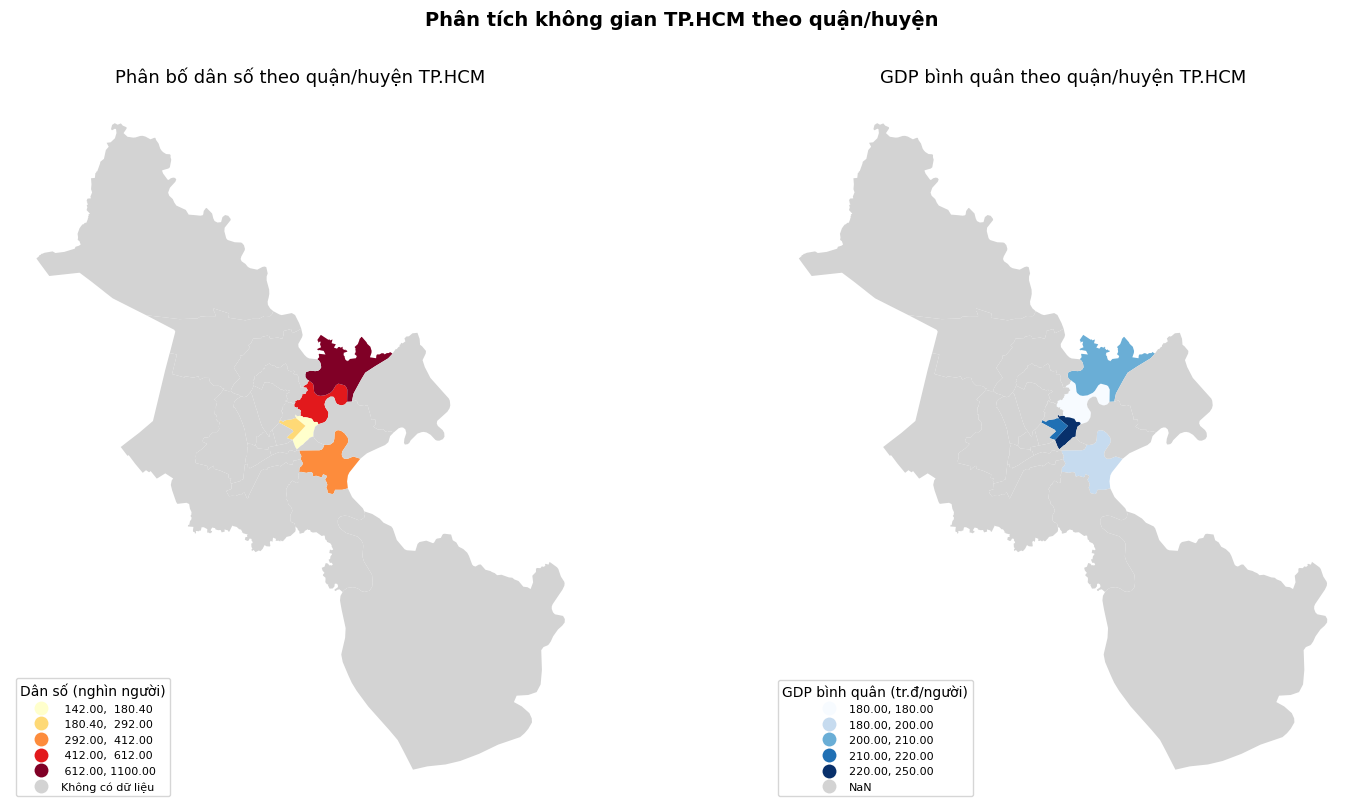

=== Thống kê dân số ===
            count    mean  std     min     25%     50%     75%     max
NAME_2                                                                
Bình Chánh    0.0     NaN  NaN     NaN     NaN     NaN     NaN     NaN
Bình Thạnh    1.0   490.0  NaN   490.0   490.0   490.0   490.0   490.0
Bình Tân      0.0     NaN  NaN     NaN     NaN     NaN     NaN     NaN
Cần Giờ       0.0     NaN  NaN     NaN     NaN     NaN     NaN     NaN
Củ Chi        0.0     NaN  NaN     NaN     NaN     NaN     NaN     NaN
Gò Vấp        0.0     NaN  NaN     NaN     NaN     NaN     NaN     NaN
Hóc Môn       0.0     NaN  NaN     NaN     NaN     NaN     NaN     NaN
Nhà Bè        0.0     NaN  NaN     NaN     NaN     NaN     NaN     NaN
Phú Nhuận     0.0     NaN  NaN     NaN     NaN     NaN     NaN     NaN
Quận 1        1.0   142.0  NaN   142.0   142.0   142.0   142.0   142.0
Quận 10       0.0     NaN  NaN     NaN     NaN     NaN     NaN     NaN
Quận 11       0.0     NaN  NaN     NaN     NaN     Na

In [67]:
#23.4
!pip install geopandas mapclassify -q
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

gdf = gpd.read_file(
    "zip+https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_VNM_shp.zip!gadm41_VNM_2.shp"
)

gdf_hcm = gdf[gdf["NAME_1"] == "Hồ Chí Minh"]

print(gdf_hcm.shape)
print(gdf_hcm.columns.tolist())
gdf_hcm.head(3)

# Dữ liệu mẫu
data = {
    "NAME_2": ["Quận 1", "Quận 3", "Quận 7", "Bình Thạnh", "Thủ Đức"],
    "dan_so": [142, 190, 360, 490, 1100],  # nghìn người
    "gdp_binh_quan": [250, 220, 200, 180, 210]  # triệu đồng/người
}

df_kt = pd.DataFrame(data)

gdf_merged = gdf_hcm.merge(df_kt, on="NAME_2", how="left")

print(gdf_merged["dan_so"].describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

#Dân số
gdf_merged.plot(
    column="dan_so",
    ax=axes[0],
    legend=True,
    cmap="YlOrRd",
    missing_kwds={"color": "lightgrey", "label": "Không có dữ liệu"},
    scheme="quantiles",
    k=5,
    legend_kwds={"title": "Dân số (nghìn người)", "loc": "lower left", "fontsize": 8}
)

axes[0].set_title("Phân bố dân số theo quận/huyện TP.HCM", fontsize=13)
axes[0].axis("off")

#GDP bình quân
gdf_merged.plot(
    column="gdp_binh_quan",
    ax=axes[1],
    legend=True,
    cmap="Blues",
    missing_kwds={"color": "lightgrey"},
    scheme="fisher_jenks",
    k=5,
    legend_kwds={"title": "GDP bình quân (tr.đ/người)", "loc": "lower left", "fontsize": 8}
)

axes[1].set_title("GDP bình quân theo quận/huyện TP.HCM", fontsize=13)
axes[1].axis("off")

plt.suptitle("Phân tích không gian TP.HCM theo quận/huyện",
             fontsize=14, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("choropleth_hcm.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== Thống kê dân số ===")
print(gdf_merged.groupby("NAME_2")["dan_so"].describe())

top5 = gdf_merged.nlargest(5, "dan_so")[["NAME_2", "dan_so"]]
print("\nTop 5 quận/huyện đông dân nhất:")
print(top5.to_string(index=False))

gdf_nonan = gdf_merged.dropna(subset=["dan_so", "gdp_binh_quan"])
corr = gdf_nonan["dan_so"].corr(gdf_nonan["gdp_binh_quan"])
print(f"\nHệ số tương quan (Pearson): {corr:.3f}")

In [68]:
#23.5
import folium
from folium import plugins
import pandas as pd
center_lat, center_lon = 10.7769, 106.7009
m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

# đánh dấu trung tâm
folium.Marker(
    [center_lat, center_lon],
    popup="Trung tâm phân phối",
    icon=folium.Icon(color='red', icon='info-sign')
).add_to(m)


ranges = [
    {"radius": 3000, "color": "green", "label": "Vùng 3km (Tối ưu)"},
    {"radius": 5000, "color": "orange", "label": "Vùng 5km (Mở rộng)"},
    {"radius": 10000, "color": "red", "label": "Vùng 10km (Tiềm năng)"}
]

for r in ranges:
    folium.Circle(
        location=[center_lat, center_lon],
        radius=r["radius"],
        color=r["color"],
        fill=True,
        fill_opacity=0.1,
        popup=r["label"]
    ).add_to(m)
m

Số lượng giao lộ (Nodes): 989 | Số lượng đoạn đường (Edges): 2090 | Tổng chiều dài đường bộ: 165.17km


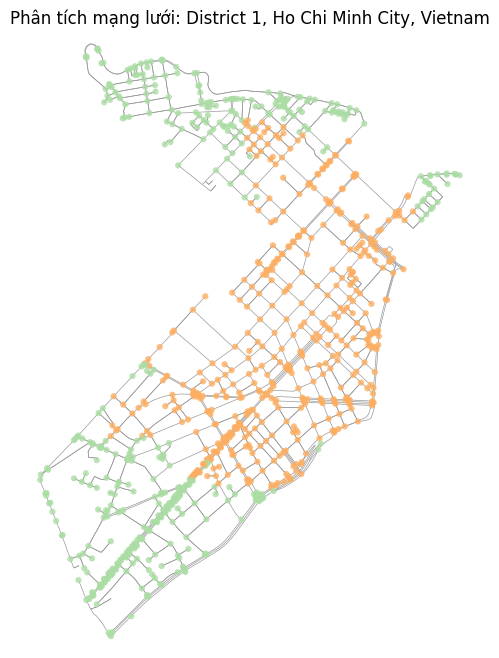

In [69]:
#23.6
!pip install osmnx networkx matplotlib -q
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

place_name = "District 1, Ho Chi Minh City, Vietnam"
center_lat, center_lon = 10.7797, 106.6990
trip_times = [5, 10, 15]
iso_colors = ['#2b83ba', '#abdda4', '#fdae61']

G = ox.graph_from_place(place_name, network_type='drive')
stats = ox.basic_stats(G)
print(f"Số lượng giao lộ (Nodes): {stats['n']} | Số lượng đoạn đường (Edges): {stats['m']} | Tổng chiều dài đường bộ: {stats['edge_length_total']/1000:.2f}km")

meters_per_min = 25 * 1000 / 60
for u, v, k, data in G.edges(data=True, keys=True):
    data['travel_time'] = data['length'] / meters_per_min

# Xác định màu sắc nút theo vùng
center_node = ox.distance.nearest_nodes(G, center_lon, center_lat)
node_colors = {}
for time, color in zip(sorted(trip_times, reverse=True), iso_colors):
    sub = nx.ego_graph(G, center_node, radius=time, distance='travel_time')
    for node in sub.nodes(): node_colors[node] = color

nc = [node_colors[node] if node in node_colors else '#ddd' for node in G.nodes()]
ns = [20 if node in node_colors else 0 for node in G.nodes()]

# Vẽ bản đồ
fig, ax = ox.plot_graph(G, node_color=nc, node_size=ns, node_alpha=0.8, edge_linewidth=0.5, bgcolor='w', show=False, close=False)
ax.set_title(f"Phân tích mạng lưới: {place_name}")
plt.show()
#vai trò của dữ liệu mạng giao thông được tinh gọn nhất:
#Làm "bản đồ số" cho AI: Cung cấp cấu trúc Nút và Cạnh để AI tính toán lộ trình và thời gian di chuyển chính xác thay vì ước tính.
#Dự báo và Điều phối: Giúp AI nhận diện nguy cơ kẹt xe và dự đoán nhu cầu dịch vụ theo từng khu vực để gán xe tối ưu.
#Quy hoạch chiến lược: Sử dụng vùng bao phủ để xác định vị trí đặt kho hàng, trạm sạc và giám sát xe theo thời gian thực.

So sánh kết quả
Chiều dài đường đi (Dijkstra): 2646.01 m
Chiều dài đường đi (A*):       2646.01 m


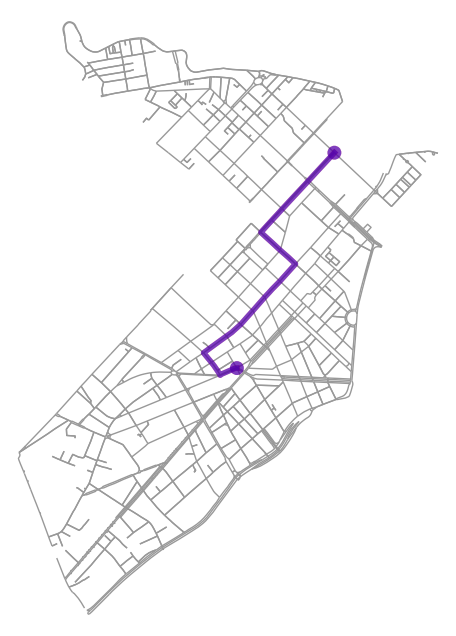

In [70]:
#23.7
!pip install osmnx networkx matplotlib -q
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import math
place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')

# điểm bắt đầu và kết thúc
coords_a = (10.7719, 106.6983)
coords_b = (10.7875, 106.7053)

origin_node = ox.distance.nearest_nodes(G, coords_a[1], coords_a[0])
destination_node = ox.distance.nearest_nodes(G, coords_b[1], coords_b[0])

# 3. Tìm đường đi bằng thuật toán Dijkstra
path_dijkstra = nx.shortest_path(G, origin_node, destination_node, weight='length', method='dijkstra')
len_dijkstra = nx.shortest_path_length(G, origin_node, destination_node, weight='length', method='dijkstra')

# 4. Tìm đường đi bằng thuật toán A*
def heuristic(u, v):
    x1, y1 = G.nodes[u]['x'], G.nodes[u]['y']
    x2, y2 = G.nodes[v]['x'], G.nodes[v]['y']
    return math.hypot(x2 - x1, y2 - y1)

path_astar = nx.astar_path(G, origin_node, destination_node, heuristic=heuristic, weight='length')
len_astar = nx.shortest_path_length(G, origin_node, destination_node, weight='length')
print(f"So sánh kết quả")
print(f"Chiều dài đường đi (Dijkstra): {len_dijkstra:.2f} m")
print(f"Chiều dài đường đi (A*):       {len_astar:.2f} m")

# 6. Trực quan hóa trên bản đồ
# Vẽ đường đi Dijkstra (màu đỏ) và A* (màu xanh)
fig, ax = ox.plot_graph_routes(G, [path_dijkstra, path_astar],
                               route_colors=['r', 'b'],
                               route_linewidth=4,
                               node_size=0,
                               bgcolor='w')
plt.show()
#So sánh Dijkstra và A*:
#Dijkstra:Tìm đường chính xác tuyệt đối bằng cách kiểm tra mọi hướng xung quanh, nhưng chậm vì duyệt nhiều nút thừa.
#A*: Nhanh hơn nhờ có "định hướng" (Heuristic) về phía đích, tập trung tìm kiếm mục tiêu thay vì dàn trải, tối ưu cho điều phối thời gian thực.

Ghép khách - tài xế:
Khách 0 -> Tài xế 2 | Khoảng cách = 18.45
Khách 1 -> Tài xế 9 | Khoảng cách = 16.55
Khách 2 -> Tài xế 8 | Khoảng cách = 15.96
Khách 3 -> Tài xế 6 | Khoảng cách = 8.30
Khách 4 -> Tài xế 7 | Khoảng cách = 37.81
Khách 5 -> Tài xế 3 | Khoảng cách = 48.96
Khách 6 -> Tài xế 5 | Khoảng cách = 22.88
Khách 7 -> Tài xế 1 | Khoảng cách = 21.36
Khách 8 -> Tài xế 0 | Khoảng cách = 49.30
Khách 9 -> Tài xế 4 | Khoảng cách = 29.27


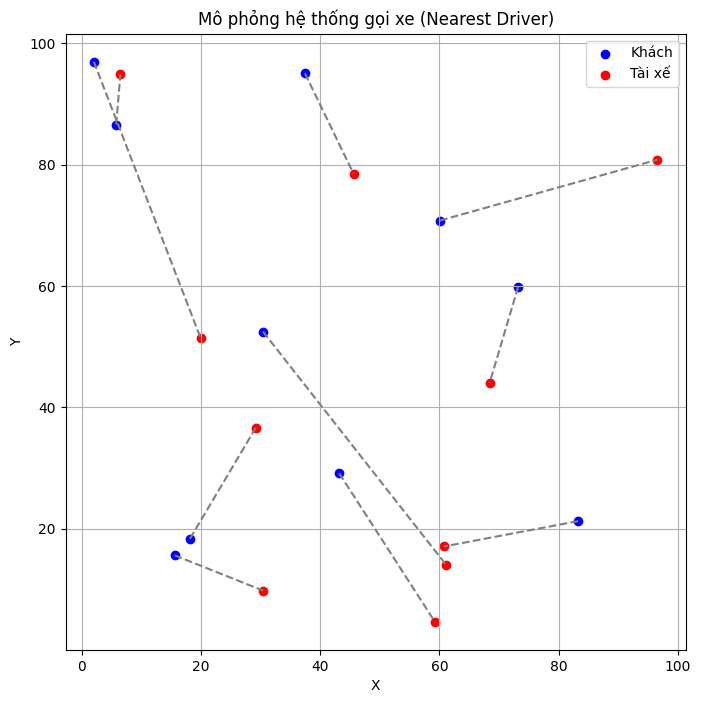

In [71]:
#23.8
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

num_customers = 10
num_drivers = 10

customers = np.random.rand(num_customers, 2) * 100
drivers = np.random.rand(num_drivers, 2) * 100

def distance(a, b):
    return np.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

matches = []
available_drivers = list(range(num_drivers))

for i, customer in enumerate(customers):
    best_driver = None
    best_dist = float('inf')

    for d in available_drivers:
        dist = distance(customer, drivers[d])
        if dist < best_dist:
            best_dist = dist
            best_driver = d

    matches.append((i, best_driver, best_dist))
    available_drivers.remove(best_driver)

print("Ghép khách - tài xế:")
for m in matches:
    print(f"Khách {m[0]} -> Tài xế {m[1]} | Khoảng cách = {m[2]:.2f}")

plt.figure(figsize=(8, 8))

# Vẽ khách
plt.scatter(customers[:,0], customers[:,1], c='blue', label='Khách')

# Vẽ tài xế
plt.scatter(drivers[:,0], drivers[:,1], c='red', label='Tài xế')

# Vẽ đường nối
for m in matches:
    c_idx, d_idx, _ = m
    x_values = [customers[c_idx][0], drivers[d_idx][0]]
    y_values = [customers[c_idx][1], drivers[d_idx][1]]
    plt.plot(x_values, y_values, 'gray', linestyle='--')

plt.legend()
plt.title("Mô phỏng hệ thống gọi xe (Nearest Driver)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)

plt.show()

In [72]:
#23.9
!pip install numpy folium scikit-learn geopy -q
import numpy as np
import folium
from sklearn.cluster import KMeans
from geopy.distance import geodesic
customers = np.array([
    [10.775, 106.700],
    [10.780, 106.705],
    [10.770, 106.690],
    [10.760, 106.680],
    [10.750, 106.675],
    [10.785, 106.710],
    [10.790, 106.720],
    [10.765, 106.695],
    [10.755, 106.685],
    [10.772, 106.702]
])

k = 3  # số trạm/kho

kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(customers)
centroids = kmeans.cluster_centers_
print("gắn khách cho trạm")

assignments = []

for i, customer in enumerate(customers):
    distances = []

    for j, centroid in enumerate(centroids):
        dist = geodesic(customer, centroid).km
        distances.append((j, dist))

    nearest = min(distances, key=lambda x: x[1])
    assignments.append((i, nearest[0], nearest[1]))

    print(f"Khách {i} → Trạm {nearest[0]} ({nearest[1]:.2f} km)")

m = folium.Map(location=[10.775, 106.700], zoom_start=13)

colors = ['red', 'blue', 'green']

# Vẽ khách
for i, point in enumerate(customers):
    folium.CircleMarker(
        location=point,
        radius=6,
        color=colors[labels[i]],
        fill=True,
        fill_opacity=0.7,
        popup=f"Khách {i} (Cụm {labels[i]})"
    ).add_to(m)

# Vẽ trạm
for i, c in enumerate(centroids):
    folium.Marker(
        location=c,
        popup=f"Trạm {i}",
        icon=folium.Icon(color='black')
    ).add_to(m)

# Vẽ đường nối khách → trạm
for (cust_idx, station_idx, _) in assignments:
    folium.PolyLine(
        [customers[cust_idx], centroids[station_idx]],
        color=colors[station_idx],
        weight=2
    ).add_to(m)
m
#Giải thích quản trị:
#Tối ưu vị trí: Đặt trạm tại trung tâm cụm để giảm quãng đường và chi phí xăng xe chặng cuối.
#Chuyên môn hóa: Phân vùng thị trường giúp quản lý nhân sự hiệu quả và rút ngắn thời gian giao hàng.

gắn khách cho trạm
Khách 0 → Trạm 1 (0.61 km)
Khách 1 → Trạm 2 (0.92 km)
Khách 2 → Trạm 1 (0.74 km)
Khách 3 → Trạm 0 (0.55 km)
Khách 4 → Trạm 0 (0.78 km)
Khách 5 → Trạm 2 (0.18 km)
Khách 6 → Trạm 2 (1.07 km)
Khách 7 → Trạm 1 (0.64 km)
Khách 8 → Trạm 0 (0.55 km)
Khách 9 → Trạm 1 (0.60 km)


In [73]:
#23.10
!pip install osmnx folium networkx pandas numpy -q
import osmnx as ox
import folium
import networkx as nx
import pandas as pd
import numpy as np
import ast, warnings
warnings.filterwarnings("ignore")

place = "Quận 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type="drive")
nodes, edges = ox.graph_to_gdfs(G)
edges = edges.reset_index()
print(f"Tải xong: {len(edges)} đoạn đường")

def parse_int(x, default):
    if isinstance(x, (list, np.ndarray)):
        if len(x) > 0:
            val_to_check = x[0]
        else:
            return default
    else:
        val_to_check = x

    if pd.isna(val_to_check):
        return default
    s = str(val_to_check).strip()
    if s.startswith("[") and s.endswith("]"):
        try:
            literal_val = ast.literal_eval(s)
            if isinstance(literal_val, (list, tuple)) and len(literal_val) > 0:
                s = str(literal_val[0])
            else:
                return default
        except (ValueError, SyntaxError):
            return default
    try:
        numeric_part = s.split(";")[0].split(",")[0].replace("mph","").replace("kph","").strip()
        return int(float(numeric_part))
    except ValueError:
        return default

edges["lanes"]     = edges["lanes"].apply(lambda x: parse_int(x, 1))
edges["maxspeed"]  = edges["maxspeed"].apply(lambda x: parse_int(x, 40))
edges["length"]    = edges["length"].apply(lambda x: parse_int(x, 100))
edges["is_oneway"] = edges["oneway"].apply(
    lambda x: 1 if pd.notna(x) and bool(x) else 0)


np.random.seed(42)
peak_hours = [7, 8, 9, 17, 18, 19]
current_hour = 8

base_vol = np.random.exponential(400, len(edges))
if current_hour in peak_hours:
    base_vol *= np.random.uniform(1.8, 2.5, len(edges))  # nhân hệ số cao điểm
edges["volume"] = base_vol.astype(int)
edges["capacity"] = edges["lanes"] * edges["maxspeed"] * 25
edges["vc_ratio"] = edges["volume"] / edges["capacity"].clip(lower=1)

def classify_risk(vc):
    if vc < 0.6:  return "Thấp",    "#1D9E75", 1.5
    if vc < 0.85: return "Trung bình", "#EF9F27", 2.5
    return              "Cao",      "#E24B4A", 4.0

edges[["risk_level","color","weight"]] = edges["vc_ratio"].apply(
    lambda v: pd.Series(classify_risk(v)))

print("\nPhân bố nguy cơ:")
print(edges["risk_level"].value_counts())
print(f"\nV/C ratio trung bình: {edges['vc_ratio'].mean():.2f}")

center = [nodes["y"].mean(), nodes["x"].mean()]
m = folium.Map(location=center, zoom_start=15, tiles="CartoDB positron")

for _, row in edges.iterrows():
    if row.geometry is None: continue
    coords = [(lat, lon) for lon, lat in row.geometry.coords]
    folium.PolyLine(
        coords,
        color=row["color"],
        weight=row["weight"],
        opacity=0.85,
        tooltip=(f"<b>Nguy cơ: {row['risk_level']}</b><br>"
                 f"V/C ratio: {row['vc_ratio']:.2f}<br>"
                 f"Lưu lượng: {row['volume']} xe/h<br>"
                 f"Số làn: {row['lanes']} | Tốc độ: {row['maxspeed']} km/h")
    ).add_to(m)

high_risk = edges[edges["risk_level"] == "Cao"]
for _, row in high_risk.iterrows():
    mid = len(row.geometry.coords) // 2
    lat, lon = row.geometry.coords[mid][1], row.geometry.coords[mid][0]
    folium.CircleMarker(
        [lat, lon], radius=5,
        color="#E24B4A", fill=True, fill_opacity=0.7,
        tooltip=f"Điểm tắc: V/C = {row['vc_ratio']:.2f}"
    ).add_to(m)

legend_html = """
<div style="position:fixed;bottom:30px;left:30px;background:white;
     padding:12px 16px;border-radius:8px;border:1px solid #ddd;
     font-size:13px;z-index:1000;line-height:2">
  <b>Nguy cơ tắc nghẽn</b><br>
  <span style="color:#E24B4A;font-size:18px">&#9644;</span> Cao &nbsp;(V/C &#x2265; 0.85)<br>
  <span style="color:#EF9F27;font-size:18px">&#9644;</span> Trung bình &nbsp;(0.6&#x2013;0.85)<br>
  <span style="color:#1D9E75;font-size:18px">&#9644;</span> Thấp &nbsp;(V/C &lt; 0.6)<br>
  <span style="color:#E24B4A">&#11044;</span> Điểm tắc nghẽn
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))
m.save("traffic_risk_map.html")
print("Đã lưu: traffic_risk_map.html")

risk_penalty = {"Thấp": 1.0, "Trung bình": 3.0, "Cao": 10.0}
e_idx = edges.set_index(["u", "v", "key"])["risk_level"]

for u, v, k, data in G.edges(keys=True, data=True):
    r = e_idx.get((u, v, k), "Thấp")
    data["weight"] = data.get("length", 100) * risk_penalty[r]

orig = ox.nearest_nodes(G, X=106.6931, Y=10.7769)
dest = ox.nearest_nodes(G, X=106.7009, Y=10.7850)

route_fast = nx.shortest_path(G, orig, dest, weight="length")
route_safe = nx.shortest_path(G, orig, dest, weight="weight")

# Vẽ 2 tuyến lên bản đồ so sánh
def route_coords(G, route):
    coords = []
    for node in route:
        n = G.nodes[node]
        coords.append((n["y"], n["x"]))
    return coords

folium.PolyLine(route_coords(G, route_fast),
    color="#E24B4A", weight=5, opacity=0.9,
    tooltip="Tuyến ngắn nhất (có thể tắc)").add_to(m)
folium.PolyLine(route_coords(G, route_safe),
    color="#185FA5", weight=5, opacity=0.9, dash_array="8",
    tooltip="Tuyến đề xuất (ít rủi ro)").add_to(m)

# Marker điểm đi / đến
folium.Marker(route_coords(G, route_safe)[0],
    popup="Điểm xuất phát",
    icon=folium.Icon(color="green", icon="play")).add_to(m)
folium.Marker(route_coords(G, route_safe)[-1],
    popup="Điểm đến",
    icon=folium.Icon(color="red", icon="flag")).add_to(m)

m.save("traffic_risk_map.html")

total = len(edges)
for level in ["Cao", "Trung bình", "Thấp"]:
    n = (edges["risk_level"] == level).sum()
    print(f"{level:12s}: {n:4d} đoạn ({100*n/total:.1f}%)")

print(f"\nTop 5 đoạn nguy cơ cao nhất:")
top5 = edges.nlargest(5, "vc_ratio")[["name","lanes","maxspeed","volume","vc_ratio"]]
print(top5.fillna("(không tên)").to_string(index=False))

m

Output hidden; open in https://colab.research.google.com to view.

Dự báo nhu cầu tại khung giờ 18


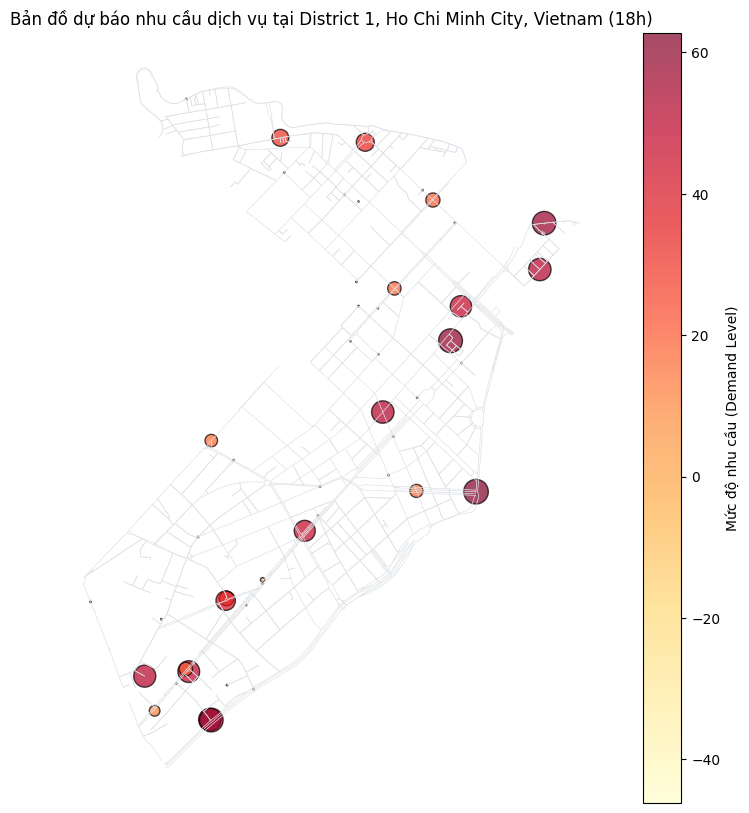

In [74]:
#23.11
!pip install osmnx pandas numpy matplotlib scikit-learn -q
import osmnx as ox
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')
nodes, edges = ox.graph_to_gdfs(G)

np.random.seed(42)
sample_points = nodes.sample(50).copy()
sample_points['hour'] = np.random.randint(7, 22, size=50)
sample_points['demand'] = 10 + 5 * np.sin(sample_points['hour'] * np.pi / 12) * 10 + np.random.normal(0, 5, 50)

X = sample_points[['hour']].values
y = sample_points['demand'].values
model = LinearRegression().fit(X, y)

target_hour = 18
predicted_demand = model.predict([[target_hour]])[0]

print(f"Dự báo nhu cầu tại khung giờ {target_hour}")

fig, ax = plt.subplots(figsize=(10, 10))
edges.plot(ax=ax, linewidth=0.5, color='#dee2e6')

sc = ax.scatter(sample_points['x'], sample_points['y'],
                c=sample_points['demand'], cmap='YlOrRd',
                s=np.maximum(1, sample_points['demand']*5), alpha=0.7, edgecolors='k') # Đảm bảo kích thước s luôn dương

plt.colorbar(sc, label='Mức độ nhu cầu (Demand Level)')
ax.set_title(f"Bản đồ dự báo nhu cầu dịch vụ tại {place_name} ({target_hour}h)")
ax.set_axis_off()
plt.show()

Tổng nhu cầu : 86 đơn vị
Số khách hàng: 8
Ma trận khoảng cách OSRM: OK

=== KẾT QUẢ TỐI ƯU HÓA ===

Kho Thủ Đức:
  Xe 1: KH_07 → KH_03 → KH_04
         Tải: 31/35 | 31.8 km
  Xe 2: KH_06 → KH_02
         Tải: 29/35 | 29.5 km
  Xe 3: KH_08 → KH_01 → KH_05
         Tải: 26/35 | 44.4 km
  Tối ưu: 105.8 km  |  Ngẫu nhiên: 106.5 km
  Tiết kiệm: 0.7 km (0.7%)

Đang tải geometry đường xe chạy...
Đã lưu: vrp_map.html


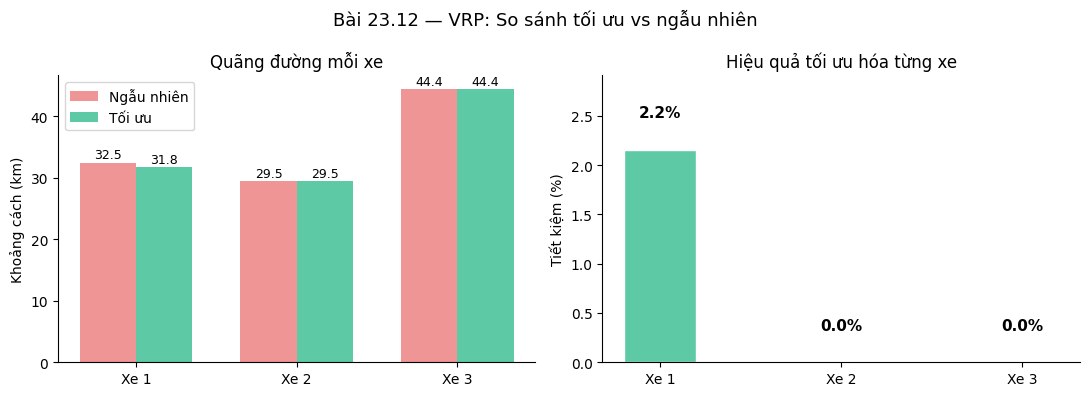

In [75]:
#23.12
!pip install numpy pandas folium matplotlib scikit-learn requests -q
import numpy as np
import pandas as pd
import folium
import random, math, time, requests
import matplotlib.pyplot as plt
from IPython.display import display

np.random.seed(42)
random.seed(42)

depots = pd.DataFrame({
    "id":   ["KHO_A"],
    "name": ["Kho Thủ Đức"],
    "lat":  [10.8500],
    "lon":  [106.7700],
})

customers = pd.DataFrame({
    "id":      [f"KH_{i:02d}" for i in range(1, 9)],
    "name":    [f"Khách hàng {i}" for i in range(1, 9)],
    "lat":     [10.762, 10.775, 10.800, 10.823, 10.755, 10.790, 10.815, 10.768],
    "lon":     [106.660, 106.700, 106.680, 106.720, 106.715, 106.740, 106.660, 106.685],
    "demand":  [10, 15, 8, 12, 9, 14, 11, 7],
})

VEHICLE_CAPACITY = 35
print(f"Tổng nhu cầu : {customers['demand'].sum()} đơn vị")
print(f"Số khách hàng: {len(customers)}")

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat, dlon = math.radians(lat2-lat1), math.radians(lon2-lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1)) * \
        math.cos(math.radians(lat2)) * math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

def build_dist_matrix(points_df):
    """Gọi OSRM /table 1 lần duy nhất → ma trận khoảng cách (km)."""
    coords_str = ";".join(
        f"{row['lon']},{row['lat']}" for _, row in points_df.iterrows())
    url = f"http://router.project-osrm.org/table/v1/driving/{coords_str}?annotations=distance"
    try:
        data = requests.get(url, timeout=15).json()
        if data.get("code") == "Ok":
            matrix = np.array(data["distances"]) / 1000  # m → km
            print("Ma trận khoảng cách OSRM: OK")
            return matrix
    except Exception as e:
        print(f"OSRM Table thất bại ({e}), dùng haversine fallback")
    # fallback
    n = len(points_df)
    mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                mat[i][j] = haversine(
                    points_df.iloc[i]["lat"], points_df.iloc[i]["lon"],
                    points_df.iloc[j]["lat"], points_df.iloc[j]["lon"])
    return mat

def osrm_geometry(lat1, lon1, lat2, lon2):
    try:
        url = (f"http://router.project-osrm.org/route/v1/driving/"
               f"{lon1},{lat1};{lon2},{lat2}"
               f"?overview=full&geometries=geojson")
        data = requests.get(url, timeout=6).json()
        if data.get("code") == "Ok":
            coords = data["routes"][0]["geometry"]["coordinates"]
            return [[lat, lon] for lon, lat in coords]
    except:
        pass
    return [[lat1, lon1], [lat2, lon2]]

all_points = pd.concat(
    [depots[["id","lat","lon"]], customers[["id","lat","lon"]]],
    ignore_index=True)
n = len(all_points)
dist_matrix = build_dist_matrix(all_points)

def nearest_neighbor_route(depot_idx, cust_indices, capacity):
    routes, unvisited = [], set(cust_indices)
    while unvisited:
        route, current, load = [], depot_idx, 0
        while unvisited:
            nearest = min(
                (c for c in unvisited
                 if load + customers.iloc[c - len(depots)]["demand"] <= capacity),
                key=lambda c: dist_matrix[current][c],
                default=None)
            if nearest is None: break
            route.append(nearest)
            load += customers.iloc[nearest - len(depots)]["demand"]
            unvisited.discard(nearest)
            current = nearest
        if route:
            routes.append(route)
    return routes

def route_distance(route, depot_idx):
    if not route: return 0
    d = dist_matrix[depot_idx][route[0]]
    for i in range(len(route)-1):
        d += dist_matrix[route[i]][route[i+1]]
    d += dist_matrix[route[-1]][depot_idx]
    return d

def two_opt(route, depot_idx):
    best, improved = route[:], True
    while improved:
        improved = False
        for i in range(len(best)-1):
            for j in range(i+2, len(best)):
                new = best[:i] + best[i:j+1][::-1] + best[j+1:]
                if route_distance(new, depot_idx) < route_distance(best, depot_idx):
                    best, improved = new, True
    return best

customer_indices = list(range(len(depots), n))

assignments = {0: customer_indices}
all_routes  = {}
total_opt = total_rand = 0

print("\n=== KẾT QUẢ TỐI ƯU HÓA ===")
for depot_idx, cust_list in assignments.items():
    depot_name = depots.iloc[depot_idx]["name"]

    routes     = nearest_neighbor_route(depot_idx, cust_list, VEHICLE_CAPACITY)
    opt_routes = [two_opt(r, depot_idx) for r in routes]
    opt_dist   = sum(route_distance(r, depot_idx) for r in opt_routes)

    shuffled = cust_list[:]
    random.shuffle(shuffled)
    rand_routes = nearest_neighbor_route(depot_idx, shuffled, VEHICLE_CAPACITY)
    rand_dist   = sum(route_distance(r, depot_idx) for r in rand_routes)

    all_routes[depot_idx] = opt_routes
    total_opt  += opt_dist
    total_rand += rand_dist

    print(f"\n{depot_name}:")
    for i, r in enumerate(opt_routes):
        ids  = [customers.iloc[c - len(depots)]["id"] for c in r]
        load = sum(customers.iloc[c - len(depots)]["demand"] for c in r)
        print(f"  Xe {i+1}: {' → '.join(ids)}")
        print(f"         Tải: {load}/{VEHICLE_CAPACITY} | "
              f"{route_distance(r, depot_idx):.1f} km")
    print(f"  Tối ưu: {opt_dist:.1f} km  |  Ngẫu nhiên: {rand_dist:.1f} km")
    if rand_dist > 0:
        print(f"  Tiết kiệm: {rand_dist-opt_dist:.1f} km "
              f"({100*(rand_dist-opt_dist)/rand_dist:.1f}%)")

m = folium.Map(location=[10.800, 106.700], zoom_start=12,
               tiles="CartoDB positron")

route_colors = ["#185FA5", "#D85A30", "#1D9E75"]

for i, row in depots.iterrows():
    folium.Marker(
        [row["lat"], row["lon"]],
        popup=f"<b>{row['name']}</b>",
        icon=folium.Icon(color="blue", icon="home", prefix="fa")
    ).add_to(m)

for _, row in customers.iterrows():
    folium.CircleMarker(
        [row["lat"], row["lon"]], radius=7,
        color="#444441", weight=1.5,
        fill=True, fill_color="#F1EFE8", fill_opacity=0.95,
        tooltip=f"<b>{row['id']}</b> | Nhu cầu: {row['demand']}"
    ).add_to(m)
    folium.Marker(
        [row["lat"], row["lon"]],
        icon=folium.DivIcon(
            html=f'<div style="font-size:8px;font-weight:bold;'
                 f'color:#2C2C2A;white-space:nowrap">{row["id"]}</div>',
            icon_size=(40,12), icon_anchor=(20,-4))
    ).add_to(m)

print("\nĐang tải geometry đường xe chạy...")
for depot_idx, routes in all_routes.items():
    depot_row = depots.iloc[depot_idx]
    for r_idx, route in enumerate(routes):
        color = route_colors[r_idx % len(route_colors)]
        waypoints = ([depot_row]
                     + [customers.iloc[c - len(depots)] for c in route]
                     + [depot_row])
        full_path = []
        for k in range(len(waypoints)-1):
            seg = osrm_geometry(
                waypoints[k]["lat"], waypoints[k]["lon"],
                waypoints[k+1]["lat"], waypoints[k+1]["lon"])
            full_path.extend(seg)
            time.sleep(0.05)
        folium.PolyLine(
            full_path, color=color, weight=4, opacity=0.85,
            tooltip=(f"<b>Xe {r_idx+1}</b> | "
                     f"{route_distance(route, depot_idx):.1f} km")
        ).add_to(m)

m.save("vrp_map.html")
print("Đã lưu: vrp_map.html")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

xe_labels = [f"Xe {i+1}" for i in range(len(all_routes[0]))]
xe_opt    = [route_distance(r, 0) for r in all_routes[0]]

shuffled2 = customer_indices[:]
random.shuffle(shuffled2)
rand2 = nearest_neighbor_route(0, shuffled2, VEHICLE_CAPACITY)
xe_rand = [route_distance(r, 0) for r in rand2]
max_len = max(len(xe_opt), len(xe_rand))
xe_opt  += [0] * (max_len - len(xe_opt))
xe_rand += [0] * (max_len - len(xe_rand))
xe_labels = [f"Xe {i+1}" for i in range(max_len)]

x, w = np.arange(max_len), 0.35
b1 = axes[0].bar(x-w/2, xe_rand, w, label="Ngẫu nhiên", color="#F09595")
b2 = axes[0].bar(x+w/2, xe_opt,  w, label="Tối ưu",     color="#5DCAA5")
for bar in [*b1, *b2]:
    if bar.get_height() > 0:
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                     f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)
axes[0].set_xticks(x); axes[0].set_xticklabels(xe_labels)
axes[0].set_ylabel("Khoảng cách (km)")
axes[0].set_title("Quãng đường mỗi xe")
axes[0].legend(); axes[0].spines[["top","right"]].set_visible(False)

savings = [100*(r-o)/r if r > 0 else 0 for r, o in zip(xe_rand, xe_opt)]
axes[1].bar(xe_labels, savings,
            color=["#5DCAA5","#1D9E75","#9FE1CB"][:max_len],
            edgecolor="white", width=0.4)
for i, pct in enumerate(savings):
    axes[1].text(i, pct+0.3, f"{pct:.1f}%",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Tiết kiệm (%)")
axes[1].set_title("Hiệu quả tối ưu hóa từng xe")
axes[1].set_ylim(0, max(savings)*1.35 if any(s>0 for s in savings) else 10)
axes[1].spines[["top","right"]].set_visible(False)

plt.suptitle("Bài 23.12 — VRP: So sánh tối ưu vs ngẫu nhiên", fontsize=13)
plt.tight_layout()
plt.savefig("vrp_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

display(m)

In [76]:
#23.13
!pip install folium pandas numpy branca -q
import folium
from folium import plugins
from folium.plugins import (HeatMap, MarkerCluster, MiniMap,
                             MeasureControl, Fullscreen, Search)
import pandas as pd
import numpy as np
import random, math, requests, time
from branca.element import Figure
from IPython.display import display

random.seed(42)
np.random.seed(42)

depots = pd.DataFrame({
    "id":       ["KHO_A", "KHO_B", "KHO_C"],
    "name":     ["Kho Bình Dương", "Kho Thủ Đức", "Kho Quận 7"],
    "lat":      [10.980, 10.850, 10.732],
    "lon":      [106.680, 106.770, 106.718],
    "capacity": [500, 350, 400],
    "type":     ["depot"] * 3,
})

customers = pd.DataFrame({
    "id":      [f"KH_{i:02d}" for i in range(1, 21)],
    "name":    [f"Khách hàng {i}" for i in range(1, 21)],
    "lat": [10.762,10.775,10.800,10.823,10.840,10.755,10.790,
            10.815,10.768,10.850,10.730,10.810,10.778,10.835,
            10.795,10.760,10.808,10.772,10.845,10.783],
    "lon": [106.660,106.700,106.680,106.720,106.695,106.715,106.740,
            106.660,106.685,106.710,106.695,106.730,106.655,106.740,
            106.705,106.672,106.698,106.725,106.715,106.688],
    "demand":   np.random.randint(5, 25, 20).tolist(),
    "revenue":  np.random.randint(10, 100, 20).tolist(),   # triệu đồng
    "priority": np.random.choice(["Cao","Trung bình","Thấp"], 20).tolist(),
    "type":     ["customer"] * 20,
})

zones = [
    {"name": "Vùng Bắc",  "color": "#B5D4F4",
     "coords": [[10.900,106.650],[10.900,106.800],[11.000,106.800],[11.000,106.650]]},
    {"name": "Vùng Trung","color": "#9FE1CB",
     "coords": [[10.780,106.640],[10.780,106.760],[10.900,106.760],[10.900,106.640]]},
    {"name": "Vùng Nam",  "color": "#FAC775",
     "coords": [[10.700,106.640],[10.700,106.760],[10.780,106.760],[10.780,106.640]]},
]

main_routes = [
    {"name": "Tuyến Bắc-Trung",
     "coords": [[10.980,106.680],[10.920,106.700],[10.850,106.720]],
     "color": "#185FA5", "distance": 18.5},
    {"name": "Tuyến Trung-Nam",
     "coords": [[10.850,106.770],[10.800,106.730],[10.732,106.718]],
     "color": "#D85A30", "distance": 14.2},
    {"name": "Tuyến Vòng",
     "coords": [[10.980,106.680],[10.850,106.680],[10.732,106.718],
                [10.780,106.770],[10.850,106.770],[10.980,106.680]],
     "color": "#1D9E75", "distance": 52.3},
]

print(f"Kho: {len(depots)} | Khách hàng: {len(customers)} | Tuyến: {len(main_routes)}")

fig = Figure(width="100%", height=700)
m = folium.Map(
    location=[10.820, 106.705],
    zoom_start=11,
    tiles="CartoDB positron",
    control_scale=True,
)
fig.add_child(m)

layer_zones = folium.FeatureGroup(name="Vùng phân tích", show=True)
for zone in zones:
    folium.Polygon(
        locations=zone["coords"],
        color=zone["color"], fill=True,
        fill_color=zone["color"], fill_opacity=0.25, weight=2,
        tooltip=f"<b>{zone['name']}</b>",
        popup=folium.Popup(
            f"<b>{zone['name']}</b><br>"
            f"Màu sắc phân vùng chiến lược", max_width=200)
    ).add_to(layer_zones)
    center_lat = sum(c[0] for c in zone["coords"]) / len(zone["coords"])
    center_lon = sum(c[1] for c in zone["coords"]) / len(zone["coords"])
    folium.Marker(
        [center_lat, center_lon],
        icon=folium.DivIcon(
            html=f'<div style="font-size:12px;font-weight:bold;'
                 f'color:#2C2C2A;background:rgba(255,255,255,0.75);'
                 f'padding:2px 6px;border-radius:4px;white-space:nowrap">'
                 f'{zone["name"]}</div>',
            icon_size=(120, 24), icon_anchor=(60, 12))
    ).add_to(layer_zones)
layer_zones.add_to(m)

layer_routes = folium.FeatureGroup(name="Tuyến đường", show=True)
for route in main_routes:
    folium.PolyLine(
        route["coords"], color=route["color"],
        weight=4, opacity=0.85,
        tooltip=f"<b>{route['name']}</b> | {route['distance']} km",
        popup=folium.Popup(
            f"<b>{route['name']}</b><br>"
            f"Khoảng cách: {route['distance']} km<br>"
            f"Màu: {route['color']}", max_width=220)
    ).add_to(layer_routes)
    mid = len(route["coords"]) // 2
    folium.Marker(
        route["coords"][mid],
        icon=folium.DivIcon(
            html=f'<div style="font-size:10px;color:{route["color"]};'
                 f'font-weight:bold">&#10148;</div>',
            icon_size=(16,16), icon_anchor=(8,8))
    ).add_to(layer_routes)
layer_routes.add_to(m)

layer_depots = folium.FeatureGroup(name="Kho hàng", show=True)
for _, row in depots.iterrows():
    folium.Marker(
        [row["lat"], row["lon"]],
        icon=folium.Icon(color="darkblue", icon="cube", prefix="fa"),
        tooltip=f"<b>{row['name']}</b> | Sức chứa: {row['capacity']}",
        popup=folium.Popup(
            f"<table style='font-size:13px'>"
            f"<tr><td><b>ID</b></td><td>{row['id']}</td></tr>"
            f"<tr><td><b>Tên</b></td><td>{row['name']}</td></tr>"
            f"<tr><td><b>Sức chứa</b></td><td>{row['capacity']} đơn vị</td></tr>"
            f"<tr><td><b>Tọa độ</b></td><td>{row['lat']:.3f}, {row['lon']:.3f}</td></tr>"
            f"</table>", max_width=260)
    ).add_to(layer_depots)
layer_depots.add_to(m)

priority_color = {"Cao": "#E24B4A", "Trung bình": "#EF9F27", "Thấp": "#1D9E75"}
layer_customers = folium.FeatureGroup(name="Khách hàng", show=True)
for _, row in customers.iterrows():
    color = priority_color[row["priority"]]
    folium.CircleMarker(
        [row["lat"], row["lon"]], radius=8,
        color=color, weight=2,
        fill=True, fill_color=color, fill_opacity=0.75,
        tooltip=(f"<b>{row['id']}</b> | {row['priority']}<br>"
                 f"Nhu cầu: {row['demand']} | Doanh thu: {row['revenue']}M"),
        popup=folium.Popup(
            f"<table style='font-size:12px;min-width:180px'>"
            f"<tr><td><b>ID</b></td><td>{row['id']}</td></tr>"
            f"<tr><td><b>Tên</b></td><td>{row['name']}</td></tr>"
            f"<tr><td><b>Ưu tiên</b></td>"
            f"<td><span style='color:{color};font-weight:bold'>"
            f"{row['priority']}</span></td></tr>"
            f"<tr><td><b>Nhu cầu</b></td><td>{row['demand']} đơn vị</td></tr>"
            f"<tr><td><b>Doanh thu</b></td><td>{row['revenue']} triệu</td></tr>"
            f"</table>", max_width=240)
    ).add_to(layer_customers)
layer_customers.add_to(m)

layer_heat = folium.FeatureGroup(name="Heatmap doanh thu", show=False)
heat_data = [[row["lat"], row["lon"], row["revenue"]]
             for _, row in customers.iterrows()]
HeatMap(heat_data, radius=25, blur=15,
        gradient={"0.2":"#B5D4F4","0.5":"#EF9F27","0.8":"#E24B4A"},
        min_opacity=0.4).add_to(layer_heat)
layer_heat.add_to(m)

layer_cluster = folium.FeatureGroup(name="Cluster khách hàng", show=False)
mc = MarkerCluster()
for _, row in customers.iterrows():
    folium.Marker(
        [row["lat"], row["lon"]],
        tooltip=row["id"],
        popup=f"{row['name']} | {row['demand']} đơn vị"
    ).add_to(mc)
mc.add_to(layer_cluster)
layer_cluster.add_to(m)

layer_bubble = folium.FeatureGroup(name="Bubble nhu cầu", show=False)
for _, row in customers.iterrows():
    folium.CircleMarker(
        [row["lat"], row["lon"]],
        radius=row["demand"] / 2,
        color="#534AB7", weight=1.5,
        fill=True, fill_color="#AFA9EC", fill_opacity=0.6,
        tooltip=f"{row['id']} | Nhu cầu: {row['demand']}"
    ).add_to(layer_bubble)
layer_bubble.add_to(m)

MiniMap(toggle_display=True, position="bottomright").add_to(m)
MeasureControl(position="topleft",
               primary_length_unit="kilometers").add_to(m)
Fullscreen(position="topleft").add_to(m)
folium.LayerControl(collapsed=False, position="topright").add_to(m)

total_revenue  = customers["revenue"].sum()
total_demand   = customers["demand"].sum()
high_priority  = (customers["priority"] == "Cao").sum()
total_distance = sum(r["distance"] for r in main_routes)

stats_html = f"""
<div style="position:fixed;top:10px;left:60px;
     background:white;padding:14px 18px;
     border-radius:10px;border:1px solid #ddd;
     font-size:12px;z-index:1000;
     box-shadow:0 2px 6px rgba(0,0,0,0.15);
     min-width:210px;line-height:2">
  <div style="font-size:14px;font-weight:bold;
       margin-bottom:6px;color:#2C2C2A">
    Dashboard Quản Trị Logistics
  </div>
  <hr style="margin:4px 0;border-color:#eee">
  <span style="color:#888">Tổng doanh thu</span><br>
  <b style="font-size:16px;color:#185FA5">{total_revenue} triệu đ</b><br>
  <span style="color:#888">Tổng nhu cầu</span><br>
  <b style="font-size:16px;color:#D85A30">{total_demand} đơn vị</b><br>
  <span style="color:#888">Khách ưu tiên cao</span><br>
  <b style="font-size:16px;color:#E24B4A">{high_priority} khách</b><br>
  <span style="color:#888">Tổng chiều dài tuyến</span><br>
  <b style="font-size:16px;color:#1D9E75">{total_distance:.1f} km</b>
</div>"""
m.get_root().html.add_child(folium.Element(stats_html))

legend_html = """
<div style="position:fixed;bottom:40px;left:10px;
     background:white;padding:12px 16px;
     border-radius:10px;border:1px solid #ddd;
     font-size:12px;z-index:1000;line-height:2;
     box-shadow:0 2px 6px rgba(0,0,0,0.15)">
  <b>Mức ưu tiên khách hàng</b><br>
  <span style="color:#E24B4A">&#11044;</span> Cao &nbsp;
  <span style="color:#EF9F27">&#11044;</span> Trung bình &nbsp;
  <span style="color:#1D9E75">&#11044;</span> Thấp<br>
  <b>Tuyến đường</b><br>
  <span style="color:#185FA5">&#9644;&#9644;</span> Bắc-Trung &nbsp;
  <span style="color:#D85A30">&#9644;&#9644;</span> Trung-Nam &nbsp;
  <span style="color:#1D9E75">&#9644;&#9644;</span> Vòng<br>
  <b>Gợi ý:</b> Bật/tắt lớp qua bảng Layer Control (góc phải)
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save("dashboard_23_13.html")
print("Đã lưu: dashboard_23_13.html")
display(m)

Kho: 3 | Khách hàng: 20 | Tuyến: 3
Đã lưu: dashboard_23_13.html


In [77]:
#23.14
import pandas as pd
import folium
from IPython.display import HTML, display

# Vị trí ban đầu của 2 xe (tọa độ thực TP.HCM)
vehicle_positions = {
    "V1": [10.7626, 106.6601],
    "V2": [10.7626, 106.6601]
}

demand_points = [
    [10.7630, 106.6610],
    [10.7640, 106.6620],
    [10.7605, 106.6585],
    [10.7592, 106.6570],
    [10.7650, 106.6640]
]

time_steps = [1, 2, 3, 4, 5]
simulation = []

for t in time_steps:
    for vehicle_id in vehicle_positions:

        if vehicle_id == "V1":
            target = demand_points[t % len(demand_points)]
        else:
            target = demand_points[(t + 1) % len(demand_points)]

        old_lat = vehicle_positions[vehicle_id][0]
        old_lon = vehicle_positions[vehicle_id][1]

        new_lat = old_lat + (target[0] - old_lat) * 0.4
        new_lon = old_lon + (target[1] - old_lon) * 0.4

        vehicle_positions[vehicle_id] = [new_lat, new_lon]

        simulation.append({
            "time": t,
            "vehicle": vehicle_id,
            "lat": new_lat,
            "lon": new_lon
        })

sim_df = pd.DataFrame(simulation)
print("Bảng mô phỏng:")
print(sim_df)

m = folium.Map(location=[10.762, 106.660], zoom_start=15)

for i, point in enumerate(demand_points):
    folium.Marker(
        point,
        popup=f"Điểm nhu cầu {i+1}",
        icon=folium.Icon(color="blue")
    ).add_to(m)

last_positions = sim_df.groupby("vehicle").tail(1)
for _, row in last_positions.iterrows():
    folium.Marker(
        [row["lat"], row["lon"]],
        popup=f"{row['vehicle']} - thời gian {row['time']}",
        icon=folium.Icon(color="red")
    ).add_to(m)

colors = {"V1": "red", "V2": "green"}
for vehicle_id, group in sim_df.groupby("vehicle"):
    coords = group[["lat", "lon"]].values.tolist()
    folium.PolyLine(
        coords,
        color=colors[vehicle_id],
        weight=3,
        opacity=0.7,
        tooltip=vehicle_id
    ).add_to(m)

display(HTML(m._repr_html_()))

Bảng mô phỏng:
   time vehicle        lat         lon
0     1      V1  10.763160  106.660860
1     1      V2  10.761760  106.659460
2     2      V1  10.762096  106.659916
3     2      V2  10.760736  106.658476
4     3      V1  10.760938  106.658750
5     3      V2  10.762442  106.660686
6     4      V1  10.762563  106.660850
7     4      V2  10.762665  106.660811
8     5      V1  10.762738  106.660910
9     5      V2  10.763199  106.661287


In [78]:
#23.15
!pip install pandas numpy folium scikit-learn -q
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster
from sklearn.cluster import KMeans
from IPython.display import HTML, display
import random

random.seed(42)
np.random.seed(42)
#Tối ưu hóa tuyến giao hàng tại TP.HCM
don_hang = pd.DataFrame({
    "id":     [f"DH{i:02d}" for i in range(1, 21)],
    "lat":    np.random.uniform(10.750, 10.800, 20),
    "lon":    np.random.uniform(106.640, 106.700, 20),
    "kg":     np.random.randint(1, 30, 20),
    "urgent": np.random.choice([True, False], 20, p=[0.3, 0.7])
})

KHO = {"lat": 10.7750, "lon": 106.6700, "name": "Kho trung tâm"}

print(" Danh sách đơn hàng:")
print(don_hang.to_string(index=False))
N_XE = 3

kmeans = KMeans(n_clusters=N_XE, random_state=42, n_init=10)
don_hang["cum"] = kmeans.fit_predict(don_hang[["lat", "lon"]])
centers = kmeans.cluster_centers_

print(f"\n Phân {len(don_hang)} đơn hàng thành {N_XE} cụm (tuyến xe):")
for c in range(N_XE):
    nhom = don_hang[don_hang["cum"] == c]
    print(f"  Xe {c+1}: {len(nhom)} đơn — tổng {nhom['kg'].sum()} kg")

COLORS  = ["red", "blue", "green"]
ICONS   = ["truck", "truck", "truck"]

m = folium.Map(location=[10.775, 106.670], zoom_start=14)

folium.Marker(
    location=[KHO["lat"], KHO["lon"]],
    popup="xe " + KHO["name"],
    icon=folium.Icon(color="black", icon="home", prefix="fa")
).add_to(m)

for cum_id in range(N_XE):
    nhom = don_hang[don_hang["cum"] == cum_id]
    color = COLORS[cum_id]

    tuyen = [[KHO["lat"], KHO["lon"]]] + nhom[["lat","lon"]].values.tolist()
    folium.PolyLine(
        tuyen,
        color=color,
        weight=2.5,
        opacity=0.6,
        tooltip=f"Xe {cum_id+1}"
    ).add_to(m)

    for _, row in nhom.iterrows():
        urgency = " Gấp" if row["urgent"] else " Thường"
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=7 + row["kg"] // 5,
            color=color,
            fill=True,
            fill_opacity=0.8,
            popup=folium.Popup(
                f"<b>{row['id']}</b><br>"
                f"Xe: {cum_id+1}<br>"
                f"Khối lượng: {row['kg']} kg<br>"
                f"Mức độ: {urgency}",
                max_width=180
            ),
            tooltip=row["id"]
        ).add_to(m)

    folium.Marker(
        location=centers[cum_id].tolist(),
        popup=f"Tâm cụm Xe {cum_id+1}",
        icon=folium.Icon(color=color, icon="star", prefix="fa")
    ).add_to(m)

legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
     background:white;padding:12px 16px;border-radius:8px;
     border:1px solid #ccc;font-size:13px;line-height:1.8">
  <b> Hệ thống giao hàng AI</b><br>
  <span style="color:red"></span> Xe 1 &nbsp;
  <span style="color:blue"></span> Xe 2 &nbsp;
  <span style="color:green"></span> Xe 3 <br>
  <span> Kho trung tâm</span><br>
  <span style="font-size:11px;color:#888">Kích thước điểm ~ khối lượng đơn</span>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

display(HTML(m._repr_html_()))

print("\n Tổng kết tuyến giao hàng:")
summary = don_hang.groupby("cum").agg(
    so_don=("id", "count"),
    tong_kg=("kg", "sum"),
    don_gap=("urgent", "sum")
).reset_index()
summary["xe"] = summary["cum"].apply(lambda x: f"Xe {x+1}")
print(summary[["xe","so_don","tong_kg","don_gap"]].to_string(index=False))

#Giá trị ứng dụng thực tiễn:
#Tự động phân chia tuyến → giảm chi phí nhiên liệu
#Ưu tiên đơn gấp → tăng sự hài lòng khách hàng
#Cân bằng tải giữa các xe → tối ưu đội xe

 Danh sách đơn hàng:
  id       lat        lon  kg  urgent
DH01 10.768727 106.676711   7   False
DH02 10.797536 106.648370  12   False
DH03 10.786600 106.657529  29   False
DH04 10.779933 106.661982   8   False
DH05 10.757801 106.667364  15   False
DH06 10.757800 106.687111   3    True
DH07 10.752904 106.651980  14    True
DH08 10.793309 106.670854  17    True
DH09 10.780056 106.675545   4   False
DH10 10.785404 106.642787  18   False
DH11 10.751029 106.676453   8    True
DH12 10.798495 106.650231   4   False
DH13 10.791622 106.643903   2   False
DH14 10.760617 106.696933   6    True
DH15 10.759091 106.697938  22   False
DH16 10.759170 106.688504  10    True
DH17 10.765212 106.658277   4   False
DH18 10.776238 106.645860  22    True
DH19 10.771597 106.681054  29   False
DH20 10.764561 106.666409  18   False

 Phân 20 đơn hàng thành 3 cụm (tuyến xe):
  Xe 1: 8 đơn — tổng 89 kg
  Xe 2: 8 đơn — tổng 112 kg
  Xe 3: 4 đơn — tổng 51 kg



 Tổng kết tuyến giao hàng:
  xe  so_don  tong_kg  don_gap
Xe 1       8       89        4
Xe 2       8      112        2
Xe 3       4       51        1
